In [1]:
## Goals for this notebook: 
### project the coordinates of the samples generated by dfmdock (same sources options as dfmdock_gridplots) into the coordinate system used by the neighborhood sampling
### plot the distribution of those samples in the transverse docking plane and the centerline axis
### write these coordinates to a dataframe so they can be plotted along with the neighborhood surface in neighborhood_plots
### compute the center of mass and variance of the samples in these coordinates - neighborhood surfaces will be recalculated with higher precision there

In [13]:
from pathlib import Path
from typing import Literal

import pandas as pd

from gridplots import load_dfmdock_stats
transplane_parent_folder = Path('../../neighborhood_sampling/transverse_plane/')
bases = {p.parent.name:p for p in transplane_parent_folder.rglob("*/basis.json")}

samples_source:Literal['darren_inference', 'dfmdock_tr_inference', 'dfmdock_inference_trtrained_deterministic'] = 'dfmdock_inference_trtrained_deterministic'
sample_stats, gt_stats, labels, limits = load_dfmdock_stats(samples_source)

dfmdock_samples_folder = Path(f'../../sample_results/{samples_source}/')

dfmdock_samples_csv = f'../../sample_results/{samples_source}/samples.csv'


samples = pd.read_csv(dfmdock_samples_csv)
samples.index = samples['index']

KeyError: 'dfmdock_inference_trtrained_deterministic'

In [14]:
import numpy as np
import ultraimport
get_centerline_direction = ultraimport("../../neighborhood_sampling/get_docking_neighborhood.py").get_centerline_direction

from tqdm import tqdm
tqdm.pandas()

samples['centers'] = samples['Filename'].progress_apply(lambda f: get_centerline_direction(dfmdock_samples_folder/f,normalize=False))

100%|██████████| 3000/3000 [01:53<00:00, 26.35it/s]


In [15]:
#I take everything back I love pandas indexing
for d in sample_stats.values():
    d['center'] = samples['centers'].loc[d.index]

In [16]:
import json
for id,df in sample_stats.items():
    basis_file = bases[id]
    with open(basis_file,"r") as f:
        basis = json.load(f)
    x = np.array(basis['plane_basis']['x'])
    y = np.array(basis['plane_basis']['y'])
    axis = basis['offset_axis']

    mat = np.linalg.inv(np.array([x,y,axis]).T)

    coords = np.dot(mat,np.stack(df['center'].values,axis=1))
    
    df['plane_x'] = coords[0]
    df['plane_y'] = coords[1]
    df['plane_offset'] = coords[2]




In [17]:
positions_df = pd.concat([sample_stats[id][['pdb_id','center','plane_x','plane_y','plane_offset']] for id in sample_stats])
positions_df.to_csv(f"docking_basis_{samples_source}_positions.csv",index_label='index')

In [6]:
sample_stats['1AVX']

,pdb_id,sample_index,c_rmsd,i_rmsd,l_rmsd,fnat,DockQ,dfmdock_energy,num_clashes,rosetta_Isc,...,diff_nll,diff_10interp_nll,forwardsde_nll,flowtime_nll,difftime_nll,diffspace_nll,center,plane_x,plane_y,plane_offset
1AVX_p0,1AVX,0,59.596889,61.769806,136.890793,0.0,0.001477,0.000000,0,NaN,...,1.017107,1.596352,6.582820,6.730589,5.657775,-3.986820,"[60.926174, -52.415653, -125.78773]",144.821001,27.943257,22.978377
1AVX_p1,1AVX,1,20.647722,22.916176,56.342743,0.0,0.008840,-16.229633,0,-12.373,...,6.857090,1.529376,6.034586,8.244396,7.289258,5.704937,"[1.793131, 28.125704, -10.888633]",-4.785856,29.352071,-5.327711
1AVX_p2,1AVX,2,6.646162,8.917461,21.816761,0.0,0.053102,-14.426113,0,-16.572,...,6.016971,3.743600,8.665766,4.557121,5.852108,3.434729,"[-15.272811, -26.28169, 9.323215]",-2.460891,-26.945905,16.696428
1AVX_p3,1AVX,3,20.615700,22.892841,56.273918,0.0,0.008860,-16.647398,0,-4.008,...,9.835377,2.365316,2.859730,4.474235,10.959633,9.038235,"[1.9533347, 28.020338, -10.996493]",-4.573500,29.326210,-5.379065
1AVX_p4,1AVX,4,7.765090,10.409405,25.464338,0.0,0.040198,-17.779541,0,-11.730,...,9.308675,3.511311,5.313909,1.451515,6.709480,7.446252,"[-16.889841, -23.986485, 12.540053]",-6.647136,-26.873246,15.859241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1AVX_p115,1AVX,115,16.831112,20.752583,51.441620,0.0,0.010592,-5.746387,2,-13.094,...,4.699945,2.839987,12.220167,4.066925,7.595581,4.786663,"[-27.291767, 21.84246, -14.766837]",-15.240578,26.365128,22.640628
1AVX_p116,1AVX,116,20.629395,22.916212,56.336308,0.0,0.008841,-16.272848,0,-9.290,...,8.823799,2.074356,6.811184,4.340392,7.735546,7.801487,"[1.9796263, 28.0778, -10.969957]",-4.604283,29.358580,-5.431045
1AVX_p117,1AVX,117,53.878887,60.566334,138.229858,0.0,0.001460,0.000000,0,NaN,...,0.670327,1.249124,6.065112,6.102818,5.094994,-4.610096,"[97.13889, 0.8268368, -93.89146]",117.829478,53.800642,-38.392213
1AVX_p118,1AVX,118,19.771051,23.060431,55.884411,0.0,0.008941,-12.239261,0,-16.004,...,4.807550,1.249084,10.865609,7.606741,9.102198,5.287878,"[15.80763, 22.37765, -11.871446]",6.347802,25.168371,-14.759072


In [7]:
df = sample_stats['1AVX']
np.stack([df['plane_x'],df['plane_y'],df['plane_offset']])

array([[144.82100097,  -4.78585571,  -2.46089106,  -4.5734997 ,
         -6.64713634,  12.72091761,  -0.78725547, -20.29679797,
         -4.72564992,  -6.73402567,  12.95045595, 114.09484859,
        150.8150554 ,  -6.97553459, -18.894306  ,  -5.42829418,
         -5.5930419 ,  -4.45859903,  -2.08153413, -18.75837194,
         98.14046048,  65.23322568, 124.72336477,   0.53334131,
         -6.5061679 ,  23.52154861, -10.16074066,  33.3998569 ,
         -0.42678199,  32.93399198,  -6.85226949, 111.03723243,
         -4.93967457,  -4.69721163,  23.08409711,  12.75027624,
         22.08866353,  -4.78054536,  -6.7464015 ,  -0.33235022,
        114.97406952,  74.03819427,  22.40840627,  24.07664642,
         -8.72664112,  34.31155478,  12.91456562,  -7.35020099,
        179.65306011,  -4.51780578,  -5.47677764,  12.34012319,
        -16.14552949,  -6.82295237, -13.12802839,  -6.98312522,
         12.75375046,  22.44531974,  13.53714704,  -4.76386835,
         -4.61397947, 161.00417129,  -4.

In [19]:
from typing import DefaultDict
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA


def plot_ellipsoid(axes:tuple[np.ndarray,np.ndarray,np.ndarray],center:np.ndarray):
    # calculate cartesian coordinates for spherical surface
    u = np.linspace(0.0, 2.0 * np.pi, 60)
    v = np.linspace(0.0, np.pi, 60)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    x2,y2,z2 = np.dot(np.stack(axes,axis=1),np.stack((x,y,z),axis=1)) + center[:,None,None]
    return x2,y2,z2


results = DefaultDict(dict)

for id,df in sample_stats.items():
    res = results[id]
    res['median_x'],res['median_y'],res['median_offset'] = res['median'] = center = df[['plane_x','plane_y','plane_offset']].median().values
    centered = df[['plane_x','plane_y','plane_offset']] - center

    pca_2d = PCA(n_components=2)
    pca_2d.fit(centered.values[:,:2])
    res['2d_svd'] = pca_2d.components_.T*np.diag(np.sqrt(pca_2d.explained_variance_)) #column matrix
    
# centers = {i:df[['plane_x','plane_y','plane_offset']].mean().values for i,df in sample_stats.items()}

# centered = {i: df[['plane_x','plane_y','plane_offset']] - centers[i] for i,df in sample_stats.items()}

# svds = {}
# for i,c in centered.items():
#     pca = PCA(n_components=3)
#     pca.fit(c.values)
#     svds[i] = (pca.components_.T*np.sqrt(pca.explained_variance_))

# svds = {i:svd(np.stack(c[['plane_x','plane_y','plane_offset']].values)) for i,c in centered.items()}


# axes = (np.array([1,0,0]),np.array([0,2,0]),np.array([0,0,4]))
# center = np.array([0,1,0])

# ex,ey,ez = plot_ellipsoid(axes,center)

# fig,ax = plt.subplots(subplot_kw={'projection':'3d'})
# ax.plot_surface(ex,ey,ez)

In [20]:
sample_stats['1AVX']['plane_y'].mean()

12.178606415191881

In [74]:
svds['1AVX']

array([[ 50.14454761,  -4.79847839,   4.1102581 ],
       [  4.1551556 ,  30.62480149,   5.77023798],
       [-12.88991698,  -8.79499167,  17.84986434]])

In [22]:
import csv
n = ['median_x','median_y','median_offset']
with open(f"{samples_source}_medians.csv","w",newline='') as f:
    dw = csv.DictWriter(f,fieldnames=['pdb_id',*n])
    dw.writeheader()
    for id in results:
        dw.writerow({'pdb_id':id,**{k:results[id][k] for k in n}})


(2,)
[[50.51251061]
 [ 0.        ]]
(2,)
[[14.25901298]
 [ 0.        ]]
(2,)
[[19.5522672]
 [ 0.       ]]
(2,)
[[4.70041554]
 [0.        ]]
(2,)
[[53.29166092]
 [ 0.        ]]
(2,)
[[37.52717298]
 [ 0.        ]]
(2,)
[[22.53266007]
 [ 0.        ]]
(2,)
[[11.56670989]
 [ 0.        ]]
(2,)
[[-1.36760315]
 [ 0.        ]]
(2,)
[[44.13970954]
 [ 0.        ]]
(2,)
[[36.5726755]
 [ 0.       ]]
(2,)
[[40.37410979]
 [ 0.        ]]
(2,)
[[40.67328844]
 [ 0.        ]]
(2,)
[[10.59626005]
 [ 0.        ]]
(2,)
[[31.57279218]
 [ 0.        ]]
(2,)
[[42.83919151]
 [ 0.        ]]
(2,)
[[20.14579447]
 [ 0.        ]]
(2,)
[[-10.93207885]
 [  0.        ]]
(2,)
[[38.12948416]
 [ 0.        ]]
(2,)
[[53.59435144]
 [ 0.        ]]
(2,)
[[47.88595982]
 [ 0.        ]]
(2,)
[[22.63560399]
 [ 0.        ]]
(2,)
[[34.72753434]
 [ 0.        ]]
(2,)
[[33.22269061]
 [ 0.        ]]
(2,)
[[51.62453797]
 [ 0.        ]]


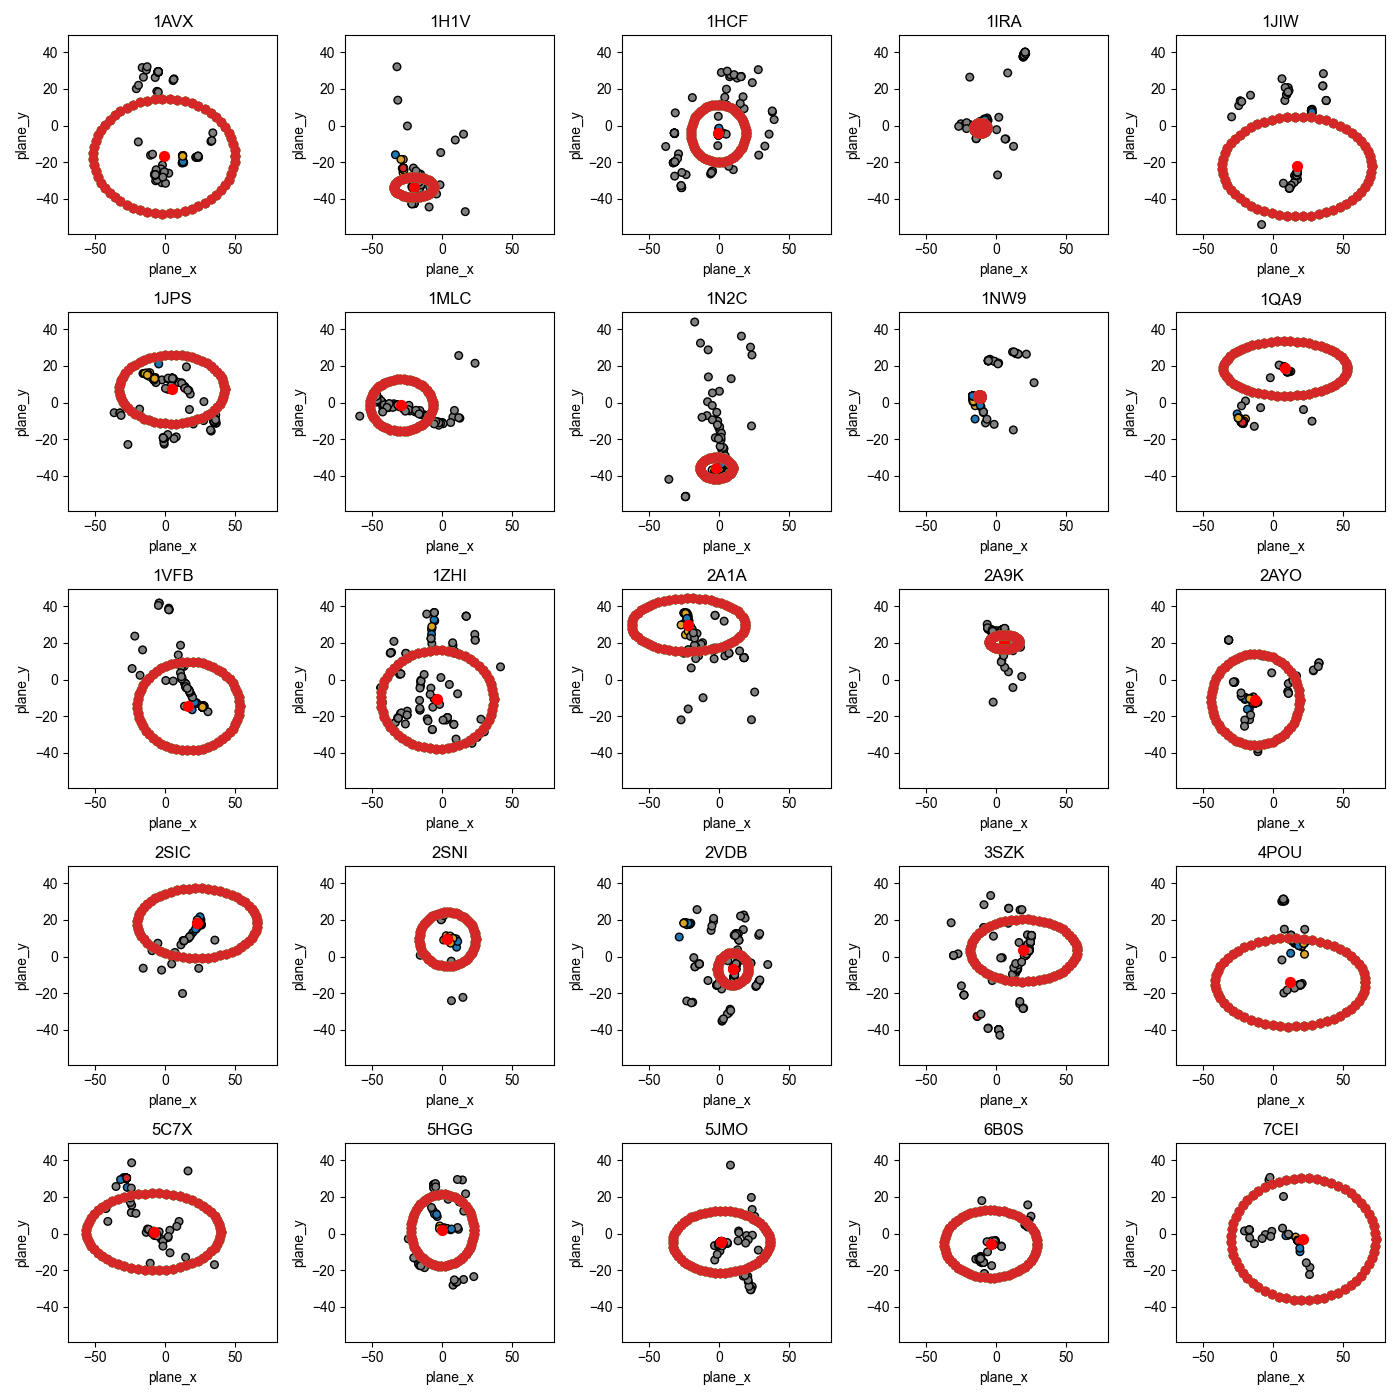

In [ ]:
%matplotlib widget
import importlib
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
import gridplots

make_gridplot = importlib.reload(gridplots).make_gridplot
fig,axes,axdict = make_gridplot(sample_stats,None,'plane_x','plane_y')

for id,df in sample_stats.items():
    ax = axdict[id]
    ax.scatter(sample_stats[id]['plane_x'].median(),sample_stats[id]['plane_y'].median(),s=50,color='red')
    # print(results[id]['median'][:2].shape)
    # print(results[id]['2d_svd'] @ np.array([[1],[0]]))

    # u = np.linspace(0.0, 2.0 * np.pi, 60)
    # cx = np.cos(u)
    # cy = np.sin(u)
    # cc = np.stack([cx,cy])
    # ax.scatter(*((results[id]['2d_svd'] @ cc) + results[id]['median'][:2,None]))
    # ax.scatter(*((results[id]['2d_svd'] @ cc) + results[id]['median'][:2,None]))
    # ax.scatter(*((results[id]['2d_svd'] @ cc) + results[id]['median'][:2,None]))
    # ax.scatter(*((results[id]['2d_svd'] @ cc) + results[id]['median'][:2,None]))
#     x,y,z = plot_ellipsoid(svds[id], centers[id])
#     ax.plot_wireframe(x,y,z)


In [28]:
sample_stats['1AVX']

,pdb_id,sample_index,c_rmsd,i_rmsd,l_rmsd,fnat,DockQ,dfmdock_energy,num_clashes,rosetta_Isc,...,diff_nll,diff_10interp_nll,forwardsde_nll,flowtime_nll,difftime_nll,diffspace_nll,center,plane_x,plane_y,plane_offset
1AVX_p0,1AVX,0,59.596889,61.769806,136.890793,0.0,0.001477,0.000000,0,NaN,...,1.017107,1.596352,6.582820,6.730589,5.657775,-3.986820,"[0.40815702, -0.3511433, -0.84267795]",0.970186,0.187198,0.153937
1AVX_p1,1AVX,1,20.647722,22.916176,56.342743,0.0,0.008840,-16.229633,0,-12.373,...,6.857090,1.529376,6.034586,8.244396,7.289258,5.704937,"[0.059349403, 0.9309101, -0.36039412]",-0.158403,0.971501,-0.176338
1AVX_p2,1AVX,2,6.646162,8.917461,21.816761,0.0,0.053102,-14.426113,0,-16.572,...,6.016971,3.743600,8.665766,4.557121,5.852108,3.434729,"[-0.48035586, -0.82660383, 0.29323095]",-0.077399,-0.847495,0.525131
1AVX_p3,1AVX,3,20.615700,22.892841,56.273918,0.0,0.008860,-16.647398,0,-4.008,...,9.835377,2.365316,2.859730,4.474235,10.959633,9.038235,"[0.064756766, 0.92892754, -0.36455467]",-0.151620,0.972220,-0.178326
1AVX_p4,1AVX,4,7.765090,10.409405,25.464338,0.0,0.040198,-17.779541,0,-11.730,...,9.308675,3.511311,5.313909,1.451515,6.709480,7.446252,"[-0.5293942, -0.75183094, 0.3930547]",-0.208347,-0.842313,0.497091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1AVX_p115,1AVX,115,16.831112,20.752583,51.441620,0.0,0.010592,-5.746387,2,-13.094,...,4.699945,2.839987,12.220167,4.066925,7.595581,4.786663,"[-0.7192029, 0.57560074, -0.38914123]",-0.401625,0.694784,0.596634
1AVX_p116,1AVX,116,20.629395,22.916212,56.336308,0.0,0.008841,-16.272848,0,-9.290,...,8.823799,2.074356,6.811184,4.340392,7.735546,7.801487,"[0.065529644, 0.9294321, -0.36312783]",-0.152411,0.971828,-0.179779
1AVX_p117,1AVX,117,53.878887,60.566334,138.229858,0.0,0.001460,0.000000,0,NaN,...,0.670327,1.249124,6.065112,6.102818,5.094994,-4.610096,"[0.71900994, 0.0061201425, -0.6949728]",0.872159,0.398226,-0.284174
1AVX_p118,1AVX,118,19.771051,23.060431,55.884411,0.0,0.008941,-12.239261,0,-16.004,...,4.807550,1.249084,10.865609,7.606741,9.102198,5.287878,"[0.5294057, 0.7494391, -0.3975809]",0.212591,0.842902,-0.494289
